In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%run DataPreparation.ipynb

In [2]:
data = dataset.iloc[:, 1:-1]
target = dataset.iloc[:, -1]

train_data, test_data, train_target, test_target = train_test_split(data, target, test_size=0.2, random_state=42)

# MODEL SELECTION

## Support Vector Machine

COARSE SEARCH

In [3]:
svr = SVR()

parameters_SVR = {'kernel': ['rbf', 'sigmoid'], 'C': [0.1, 1, 10], 'gamma': [1e-3, 1e-2]}

search = GridSearchCV(svr, param_grid=parameters_SVR)

search.fit(train_data, train_target)
print(f"Best coarse search parameters: {search.best_params_}")

Best coarse search parameters: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}


FINE SEARCH

In [4]:
svr.set_params(kernel='rbf')

parameters_fine_SVR = {'C':[9, 10, 11], 'gamma': [1e-3, 2e-3, 5e-4]}

search_fine = GridSearchCV(svr, param_grid=parameters_fine_SVR)

search_fine.fit(train_data, train_target)
print(f"Best fine search parameters: {search_fine.best_params_}")

Best fine search parameters: {'C': 11, 'gamma': 0.0005}


In [5]:
svr.set_params(C=search_fine.best_params_['C'], gamma=search_fine.best_params_['gamma'])

scores = cross_val_score(svr, train_data, train_target, cv=5, scoring='r2')
print(f"Cross validation R² scores: {scores}")
print(f'Mean of R² scores: {np.mean(scores):.3f}')
print(f'R² scores standard deviation: {np.std(scores):.4f}')

Cross validation R² scores: [-0.04620033 -0.11409101 -0.01557072 -0.03276817 -0.054281  ]
Mean of R² scores: -0.053
R² scores standard deviation: 0.0334


## XGBoost

COARSE SEARCH

In [6]:
xgb = XGBRegressor(n_jobs=-1)

parameters_XGB = {'n_estimators': [100,500,1000], 'max_depth': [3, 7, 10], 'learning_rate': [1e-2, 1e-3], 'gamma': [0, 0.1, 0.3, 1]}

search = GridSearchCV(xgb, param_grid=parameters_XGB, n_jobs=-1)

search.fit(train_data, train_target)
print(f"Best coarse search parameters: {search.best_params_}")

Best coarse search parameters: {'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 1000}


FINE SEARCH

In [7]:
xgb.set_params(gamma=search.best_params_['gamma'],max_depth=search.best_params_['max_depth'])

fine_parameters_XGB = {'n_estimators':[1000, 1500, 2000], 'learning_rate':[0.01, 0.05, 0.07]}

fine_search = GridSearchCV(xgb, param_grid=fine_parameters_XGB, n_jobs=-1)

fine_search.fit(train_data, train_target)
print(f"Best fine search parameters: {fine_search.best_params_}")

Best fine search parameters: {'learning_rate': 0.05, 'n_estimators': 1000}


In [8]:
xgb.set_params(n_estimators=fine_search.best_params_['n_estimators'], learning_rate=fine_search.best_params_['learning_rate'])

scores = cross_val_score(xgb, train_data, train_target, cv=5, scoring='r2')
print(f"Cross validation R² scores: {scores}")
print(f'Mean of R² scores: {np.mean(scores):.3f}')
print(f'R² scores standard deviation: {np.std(scores):.4f}')

Cross validation R² scores: [0.83507907 0.77013379 0.87695813 0.88485068 0.91042703]
Mean of R² scores: 0.855
R² scores standard deviation: 0.0491


## Random Forest

Coarse Search

In [9]:
rand_f = RandomForestRegressor(n_jobs=1)

parameters_RandF = {'n_estimators': [100,200,500], 'max_depth': [None, 10, 20, 30], 'max_features': ['sqrt', 'log2', 0.5], 'min_samples_split': [2, 5, 10, 20], 'bootstrap':[True, False]}

search = GridSearchCV(rand_f, param_grid=parameters_RandF, n_jobs=-1)

search.fit(train_data, train_target)
print(f"Best coarse search parameters: {search.best_params_}")

Best coarse search parameters: {'bootstrap': False, 'max_depth': 30, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}


Fine search

In [10]:
rand_f.set_params(bootstrap=search.best_params_['bootstrap'], max_features=search.best_params_['max_features'], min_samples_split=search.best_params_['min_samples_split'])

fine_parameteres_RandF = {'max_depth':[30, 40, 50, 60], 'n_estimators':[200, 300, 350, 400]}

fine_search = GridSearchCV(rand_f, param_grid=fine_parameteres_RandF, n_jobs=-1)

fine_search.fit(train_data, train_target)
print(f"Best fine search parameters: {fine_search.best_params_}")

Best fine search parameters: {'max_depth': 60, 'n_estimators': 350}


In [11]:
rand_f.set_params(n_estimators=fine_search.best_params_['n_estimators'], max_depth=fine_search.best_params_['max_depth'])

scores = cross_val_score(rand_f, train_data, train_target, cv=5, scoring='r2')
print(f"Cross validation R² scores: {scores}")
print(f'Mean of R² scores: {np.mean(scores):.3f}')
print(f'R² scores standard deviation: {np.std(scores):.4f}')

Cross validation R² scores: [0.86583293 0.80151173 0.81203741 0.88219986 0.90426186]
Mean of R² scores: 0.853
R² scores standard deviation: 0.0399


## AdaBoost

Coarse search

In [12]:
adaBR = AdaBoostRegressor()

parameters_AdaB = {'n_estimators': [50,100,200,400], 'learning_rate': [0.01, 0.05, 0.1, 0.001], 'loss': ['linear', 'square', 'exponential'], 
                   'estimator':[
                       DecisionTreeRegressor(max_depth=1),
                       DecisionTreeRegressor(max_depth=2),
                       DecisionTreeRegressor(max_depth=3)
                   ]}

search = GridSearchCV(adaBR, param_grid=parameters_AdaB, n_jobs=-1)

search.fit(train_data, train_target)
print(f"Best coarse search parameters: {search.best_params_}")

Best coarse search parameters: {'estimator': DecisionTreeRegressor(max_depth=3), 'learning_rate': 0.1, 'loss': 'linear', 'n_estimators': 200}


Fine search

In [13]:
adaBR.set_params(estimator=search.best_params_['estimator'], loss=search.best_params_['loss'])

fine_parameters_adaB = {'n_estimators': [400, 500, 600], 'learning_rate': [0.1, 0.5, 1]}

fine_search = GridSearchCV(adaBR, param_grid=fine_parameters_adaB, n_jobs=-1)

fine_search.fit(train_data, train_target)
print(f'Best fine search parameters: {fine_search.best_params_}')

Best fine search parameters: {'learning_rate': 0.1, 'n_estimators': 600}


In [14]:
adaBR.set_params(n_estimators=search.best_params_['n_estimators'], learning_rate=search.best_params_['learning_rate'])

scores = cross_val_score(adaBR, train_data, train_target, cv=5, scoring='r2')
print(f"Cross validation R² scores: {scores}")
print(f'Mean of R² scores: {np.mean(scores):.3f}')
print(f'R² scores standard deviation: {np.std(scores):.4f}')

Cross validation R² scores: [0.81261479 0.66916488 0.75728235 0.80320066 0.81247191]
Mean of R² scores: 0.771
R² scores standard deviation: 0.0549


## Models R² Score, MAE and MSE

In [15]:
svr.fit(train_data, train_target)

preds = svr.predict(test_data)

svr_r2 = r2_score(test_target, preds)
svr_mae = mean_absolute_error(test_target, preds)
svr_mse = mean_squared_error(test_target, preds)

print(f"SVM R² score: {svr_r2:.3f}")
print(f"SVM MAE score: {svr_mae:.2f}")

SVM R² score: -0.025
SVM MAE score: 59567.38


In [16]:
xgb.fit(train_data, train_target)

predx = xgb.predict(test_data)

xgb_r2 = r2_score(test_target, predx)
xgb_mae = mean_absolute_error(test_target, predx)
xgb_mse = mean_squared_error(test_target, predx)

print(f"XGBoost R² score: {xgb_r2:.3f}")
print(f"XGBoost MAE score: {xgb_mae:.2f}")

XGBoost R² score: 0.913
XGBoost MAE score: 16044.83


In [17]:
rand_f.fit(train_data, train_target)

predr = rand_f.predict(test_data)

randf_r2 = r2_score(test_target, predr)
randf_mae = mean_absolute_error(test_target, predr)
randf_mse = mean_squared_error(test_target, predr)

print(f"Random Forest R² score: {randf_r2:.3f}")
print(f"Random Forest MAE score: {randf_mae:.2f}")

Random Forest R² score: 0.887
Random Forest MAE score: 16817.81


In [18]:
adaBR.fit(train_data, train_target)

preda = adaBR.predict(test_data)

ada_r2 = r2_score(test_target, preda)
ada_mae = mean_absolute_error(test_target, preda)
ada_mse = mean_squared_error(test_target, preda)

print(f"AdaBoost R² score: {ada_r2:.3f}")
print(f"AdaBoost MAE score: {ada_mae:.2f}")

AdaBoost R² score: 0.851
AdaBoost MAE score: 23418.47


### Evaluating models

In [19]:
models = ['SVM', 'XGBoost', 'Random Forest', 'AdaBoost']

r2_scores = [svr_r2, xgb_r2, randf_r2, ada_r2]

mae = [svr_mae, xgb_mae, randf_mae, ada_mae]

mse = [svr_mse, xgb_mse, randf_mse, ada_mse]

R² Score

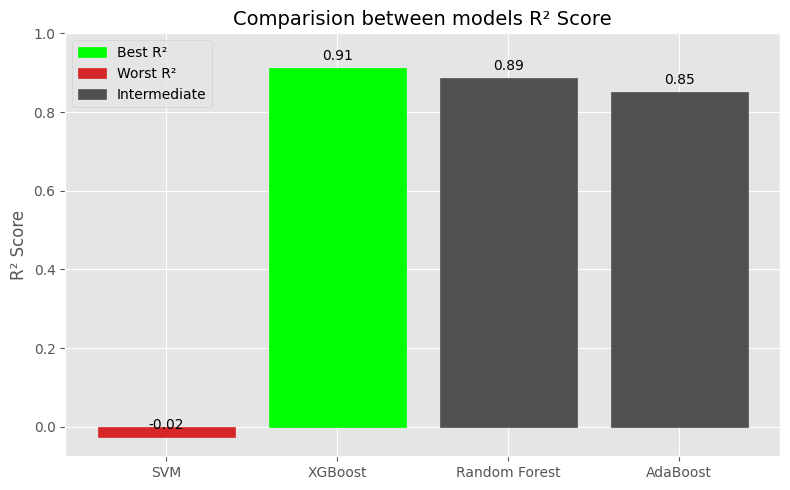

In [20]:
plt.style.use('ggplot')  

fig, ax = plt.subplots(figsize=(8,5))

colors = ['#d62728', "#00ff00", "#505053"]

bars = ax.bar(models, r2_scores, color=colors)

ax.set_title('Comparision between models R² Score', fontsize=14)
ax.set_ylabel('R² Score')

max_idx = r2_scores.index(max(r2_scores))
min_idx = r2_scores.index(min(r2_scores))

for i, bar in enumerate(bars):
    if i == max_idx:
        bar.set_color(colors[1])  
    elif i == min_idx:
        bar.set_color(colors[0]) 
    else:
        bar.set_color(colors[2])  
ax.set_ylim(min(r2_scores)-0.05, 1)

best = mpatches.Patch(color=colors[1], label='Best R²')
worst = mpatches.Patch(color=colors[0], label='Worst R²')
interm = mpatches.Patch(color=colors[2], label='Intermediate')

ax.legend(handles=[best, worst, interm])

for bar in bars:
    altura = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, altura + 0.02,
            f'{altura:.2f}',
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()

MAE

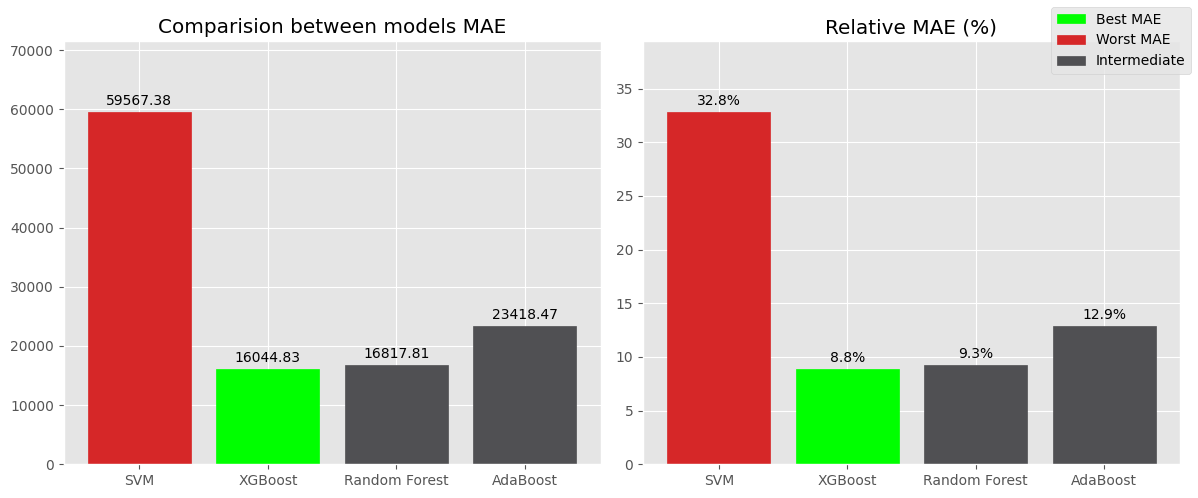

In [21]:
mean_prices = np.mean(train_target)
mae_rel = [(m / mean_prices) * 100 for m in mae]

max_idx = np.argmax(mae)  
min_idx = np.argmin(mae)  

fig, axs = plt.subplots(1, 2, figsize=(12,5))

bars1 = axs[0].bar(models, mae)

for i, bar in enumerate(bars1):
    if i == min_idx:
        bar.set_color(colors[1])
    elif i == max_idx:
        bar.set_color(colors[0])
    else:
        bar.set_color(colors[2])

axs[0].set_title('Comparision between models MAE')
axs[0].set_ylim(0, max(mae) * 1.2)

for i, v in enumerate(mae):
    axs[0].text(i, v + max(mae)*0.02, f'{v:.2f}', ha='center')

bars2 = axs[1].bar(models, mae_rel)

for i, bar in enumerate(bars2):
    if i == min_idx:
        bar.set_color(colors[1])
    elif i == max_idx:
        bar.set_color(colors[0])
    else:
        bar.set_color(colors[2])

axs[1].set_title('Relative MAE (%)')
axs[1].set_ylim(0, max(mae_rel) * 1.2)

for i, v in enumerate(mae_rel):
    axs[1].text(i, v + max(mae_rel)*0.02, f'{v:.1f}%', ha='center')


best = mpatches.Patch(color=colors[1], label='Best MAE')
worst = mpatches.Patch(color=colors[0], label='Worst MAE')
interm = mpatches.Patch(color=colors[2], label='Intermediate')

fig.legend(handles=[best, worst, interm], loc='upper right', ncol=1)

plt.tight_layout()
plt.show()

### Selected models: XGBoost & Random Forest

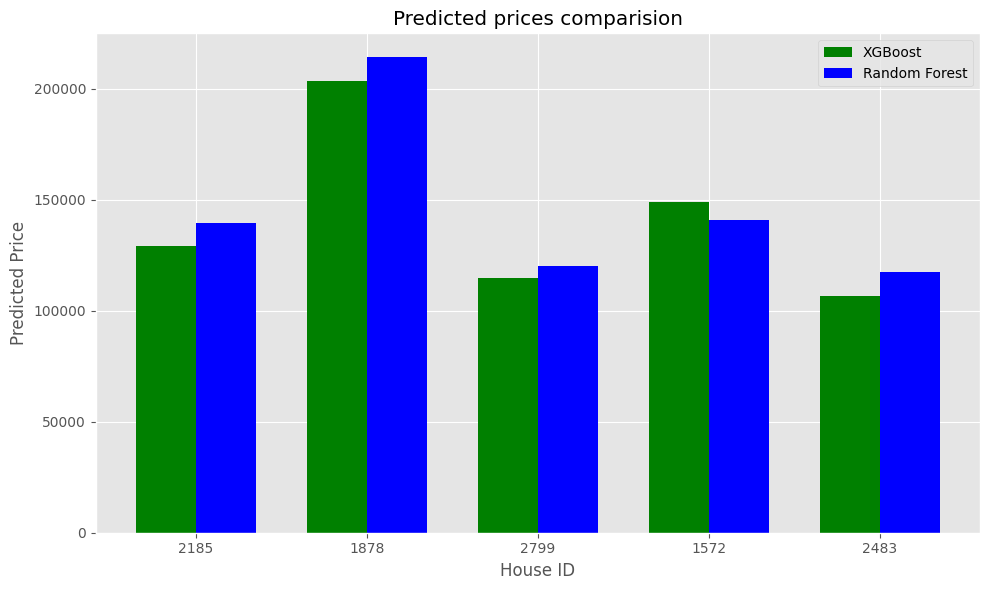

In [22]:
from random import randint

houses = []
xgb_preds = []
rf_preds = []

for i in range(5):
    idx = randint(0, 1461)
    
    house_id = test.iloc[idx, 0]
    predx = xgb.predict(test.iloc[[idx], 1:])[0]
    predr = rand_f.predict(test.iloc[[idx], 1:])[0]
    
    houses.append(str(house_id))
    xgb_preds.append(predx)
    rf_preds.append(predr)

x = range(len(houses))

width = 0.35

plt.figure(figsize=(10,6))

plt.bar([i - width/2 for i in x], xgb_preds, width=width, label='XGBoost', color='green')
plt.bar([i + width/2 for i in x], rf_preds, width=width, label='Random Forest', color='blue')

plt.xticks(x, houses)
plt.xlabel("House ID")
plt.ylabel("Predicted Price")
plt.title("Predicted prices comparision")

plt.legend()
plt.tight_layout()
plt.show()